# LFP Analysis Pipeline — Example Notebook

**Author:** Juliana Groß  
**Pipeline:** LFP branch — preprocessing → PSD analysis → FOOOF parameterization

---

## Overview

This notebook walks through the complete LFP analysis pipeline step by step. It is intended to accompany the published scripts and provide an executable, annotated example to understand or reproduce the analysis.

The pipeline consists of the following scripts, executed in order:

| Step | Script | Purpose |
|------|--------|---------|
| 1 | `experiments_differential_ref_pairs.py` | Define electrode reference pairs per animal and region |
| 2 | `common_ingest.py` | Build a `run_manifest.json` per recording folder |
| 3a | `preprocessing_lfp.py` | Lowpass filter + differential referencing (LMR) |
| 3b | `preprocessing_lfp_car.py` | Lowpass filter + Common Average Reference (CAR, for floating-reference animals) |
| 4 | `process_lfp_psd.py` | Welch PSD → group comparison → Cohen's d + bootstrap CI |
| 5 | `process_lfp_fooof.py` | FOOOF/specparam parameterization of aperiodic and periodic components |

Helper functions shared across preprocessing scripts are defined in `Functions_preprocessing_lfp.py`.

---

## Important note on the example dataset

**The example dataset used in this notebook is synthetically generated by Claude (Anthropic) for illustrative purposes.** It is not derived from real recordings. The synthetic signals are designed to mimic the statistical properties of real dCA1 LFP data — including a 1/f aperiodic background, a theta peak (~7 Hz), and a stimulation-induced reduction in broadband power — but they do not represent actual experimental observations.

Real data were recorded using a Tucker-Davis Technologies (TDT) system at 24 kHz with 6-wire tetrode bundles implanted bilaterally in dCA1 of freely moving mice.

---
## Setup & Imports

In [1]:
# Standard library
import os
import json
import pickle
import tempfile
from pathlib import Path

# Numerical
import numpy as np
import pandas as pd

# Signal processing
from scipy.signal import welch, firwin, filtfilt, iirnotch
from scipy.ndimage import label as ndlabel

# Plotting
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# FOOOF / specparam
try:
    from specparam import SpectralModel as FOOOF
    print("specparam imported successfully")
except ImportError:
    print("specparam not found. Install with: pip install specparam")

# Notebook display settings
%matplotlib inline
plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 10,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

print("All imports successful.")

specparam imported successfully
All imports successful.


---
## Step 1 — Experiment Dictionary (`experiments_differential_ref_pairs.py`)

Every recording session is registered in the experiment dictionary before analysis begins. For each animal and region, the following are specified:

- **`ref_pairs`**: pairs of electrode channels used for differential (local-field) referencing. The signal from one channel is subtracted from the other to remove common-mode noise while preserving local field activity.
- **`noise_ref`**: a single channel with no electrode connected, used to record environmental noise for NLMS adaptive filtering.
- **Filter and downsampling settings**: applied uniformly across all channels of a session.

Below is a minimal example reproducing the structure used in the actual pipeline.

In [2]:
def experiment_add(experiments, ID, region="not defined", noise_ref=None,
                   ref_pairs=None, filter_type="FIR", delta1=0.00001,
                   delta2=0.0001, transition_width=50, cutoff=100,
                   num_taps=None, order=4, downsampling=1000):
    """Register one animal/region entry in the experiment dictionary."""
    if ref_pairs is None:
        ref_pairs = []
    if ID not in experiments:
        experiments[ID] = {}
    experiments[ID][region] = {
        "region": region,
        "noise_ref": noise_ref,
        "ref_pairs": ref_pairs,
        "filter": {
            "type": filter_type, "delta1": delta1, "delta2": delta2,
            "transition_width": transition_width, "cutoff": cutoff,
            "num_taps": num_taps, "order": order,
        },
        "downsampling_Hz": downsampling,
    }
    return experiments

# Example: one ChR2 animal, left CA1, three differential pairs
experiments = {}
experiments = experiment_add(
    experiments,
    ID='ID1099-250114-121824',
    region='CA1_L',
    noise_ref=8,
    ref_pairs=[[31, 29], [27, 25], [23, 21]],  # [signal ch, reference ch]
)

print("Experiment dictionary entry:")
print(json.dumps(experiments['ID1099-250114-121824']['CA1_L'], indent=2))

Experiment dictionary entry:
{
  "region": "CA1_L",
  "noise_ref": 8,
  "ref_pairs": [
    [
      31,
      29
    ],
    [
      27,
      25
    ],
    [
      23,
      21
    ]
  ],
  "filter": {
    "type": "FIR",
    "delta1": 1e-05,
    "delta2": 0.0001,
    "transition_width": 50,
    "cutoff": 100,
    "num_taps": null,
    "order": 4
  },
  "downsampling_Hz": 1000
}


---
## Step 2 — Ingest & Manifest (`common_ingest.py`)

`common_ingest.py` reads the experiment dictionary and creates a `run_manifest.json` for each recording folder. The manifest is the **single source of truth** for all downstream scripts — it stores paths, channel assignments, filter settings, and metadata references so that processing parameters are fully reproducible.

Below we build a minimal in-memory manifest to illustrate its structure.

In [3]:
# Simulated manifest — in the real pipeline this is written to disk
# as run_manifest.json by common_ingest.py
manifest = {
    "schema_version": "1.0",
    "folder": "ID1099-250114-121824",
    "block_path": "/data/raw/ChR2_cohort/OFT/ID1099-250114-121824",
    "processed_folder_path": "/data/processed/ChR2_cohort/OFT/ID1099-250114-121824",
    "noise_reference_channel": 8,
    "regions": [
        {
            "region_name": "CA1_L",
            "ref_pairs": [[31, 29], [27, 25], [23, 21]],
            "channels_unreferenced": [21, 23, 25, 27, 29, 31],
            "lfp_settings": {
                "filter": {
                    "type": "FIR", "delta1": 0.00001, "delta2": 0.0001,
                    "transition_width": 50, "cutoff": 100,
                    "num_taps": None, "order": 4,
                },
                "downsampling_Hz": 1000,
            },
        }
    ],
}

print("Manifest structure:")
print(f"  folder              : {manifest['folder']}")
print(f"  regions             : {[r['region_name'] for r in manifest['regions']]}")
print(f"  noise ref channel   : {manifest['noise_reference_channel']}")
print(f"  ref_pairs (CA1_L)   : {manifest['regions'][0]['ref_pairs']}")
print(f"  downsampling target : {manifest['regions'][0]['lfp_settings']['downsampling_Hz']} Hz")

Manifest structure:
  folder              : ID1099-250114-121824
  regions             : ['CA1_L']
  noise ref channel   : 8
  ref_pairs (CA1_L)   : [[31, 29], [27, 25], [23, 21]]
  downsampling target : 1000 Hz


---
## Step 3 — Preprocessing (`preprocessing_lfp.py` / `preprocessing_lfp_car.py`)

Raw LFP signals are recorded at 24 kHz. Preprocessing involves three steps:

1. **Lowpass filter** (FIR, cutoff 100 Hz) to remove high-frequency content above the LFP band
2. **Referencing** — either differential (LMR: local field subtraction of a paired electrode) or Common Average Reference (CAR) for animals with floating headstage configuration
3. **Downsampling** to 1000 Hz (polyphase rational resampling)

Below we generate a synthetic LFP signal and apply these steps.

Synthetic LFP: 14400000 samples | 24000 Hz | 600 s


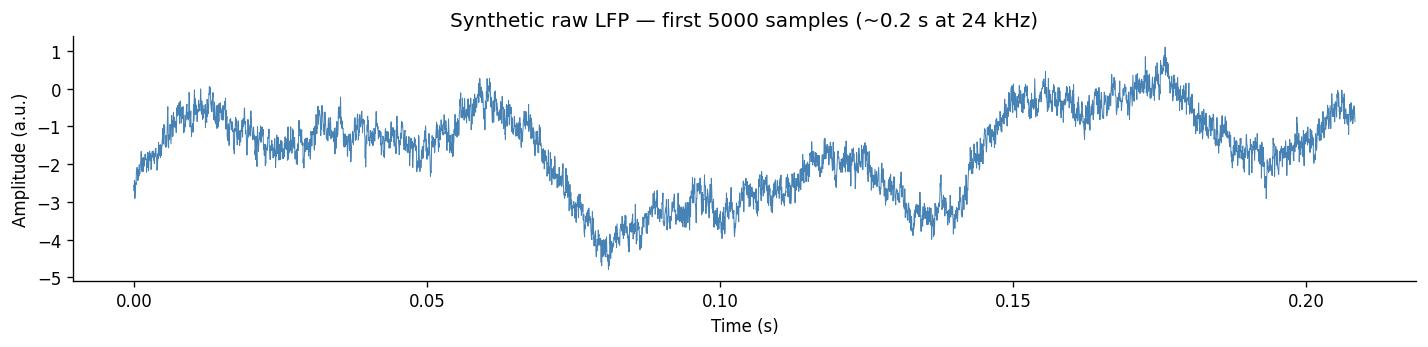

In [26]:
# ── Synthetic LFP signal generator ──────────────────────────────────────────
# NOTE: This signal is synthetically generated for illustration only.
# It is not derived from real recordings.

def generate_synthetic_lfp(fs=24000, duration_s=600, seed=42,
                            noise_floor=0.5, stim_suppression=0.5):
    """
    Generate a synthetic LFP signal with:
      - 1/f aperiodic background
      - Multiple oscillatory components spanning delta to gamma:
          delta (~2 Hz), theta (~7 Hz), beta (~20 Hz), gamma (~35 Hz)
      - Baseline epoch (300 s) + stimulation epoch (300 s)
      - Stimulation reduces broadband power and suppresses theta/beta peaks
    This multi-peak structure ensures a realistic CF distribution for FOOOF.
    """
    rng = np.random.default_rng(seed)
    n   = int(fs * duration_s)
    t   = np.arange(n) / fs

    # 1/f aperiodic background
    white    = rng.standard_normal(n)
    fft_freq = np.fft.rfftfreq(n, 1 / fs)
    fft_freq[0] = 1e-6
    power    = 1.0 / fft_freq ** 1.0
    pink     = np.fft.irfft(np.fft.rfft(white) * np.sqrt(power), n=n)
    pink    *= noise_floor / pink.std()

    # Oscillatory components: [frequency_hz, amplitude]
    oscillations = [
        (2.0,  0.6),   # delta
        (7.0,  1.5),   # theta (dominant in dCA1)
        (20.0, 0.8),   # beta
        (35.0, 0.5),   # low gamma
    ]
    osc_signal = sum(amp * np.sin(2 * np.pi * hz * t) for hz, amp in oscillations)

    signal = pink + osc_signal

    # Stimulation: reduce broadband power + attenuate theta and beta peaks
    baseline_s = 300
    stim_start = int(baseline_s * fs)
    signal[stim_start:] *= (1 - stim_suppression)
    # Additional selective suppression of theta during stimulation
    theta_stim = 0.7 * np.sin(2 * np.pi * 7.0 * t[stim_start:])
    signal[stim_start:] -= theta_stim

    return t, signal, fs


# Generate 600 s total: 300 s baseline + 300 s stimulation
# This matches the window settings used in the real pipeline
t_raw, lfp_raw, fs_raw = generate_synthetic_lfp(duration_s=600)
print(f"Synthetic LFP: {len(lfp_raw)} samples | {fs_raw} Hz | {len(lfp_raw)/fs_raw:.0f} s")

# Quick preview
fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(t_raw[:5000], lfp_raw[:5000], lw=0.6, color='steelblue')
ax.set_xlabel("Time (s)"); ax.set_ylabel("Amplitude (a.u.)")
ax.set_title("Synthetic raw LFP — first 5000 samples (~0.2 s at 24 kHz)")
plt.tight_layout()
plt.show()

FIR filter: cutoff=100.0 Hz | num_taps=2560


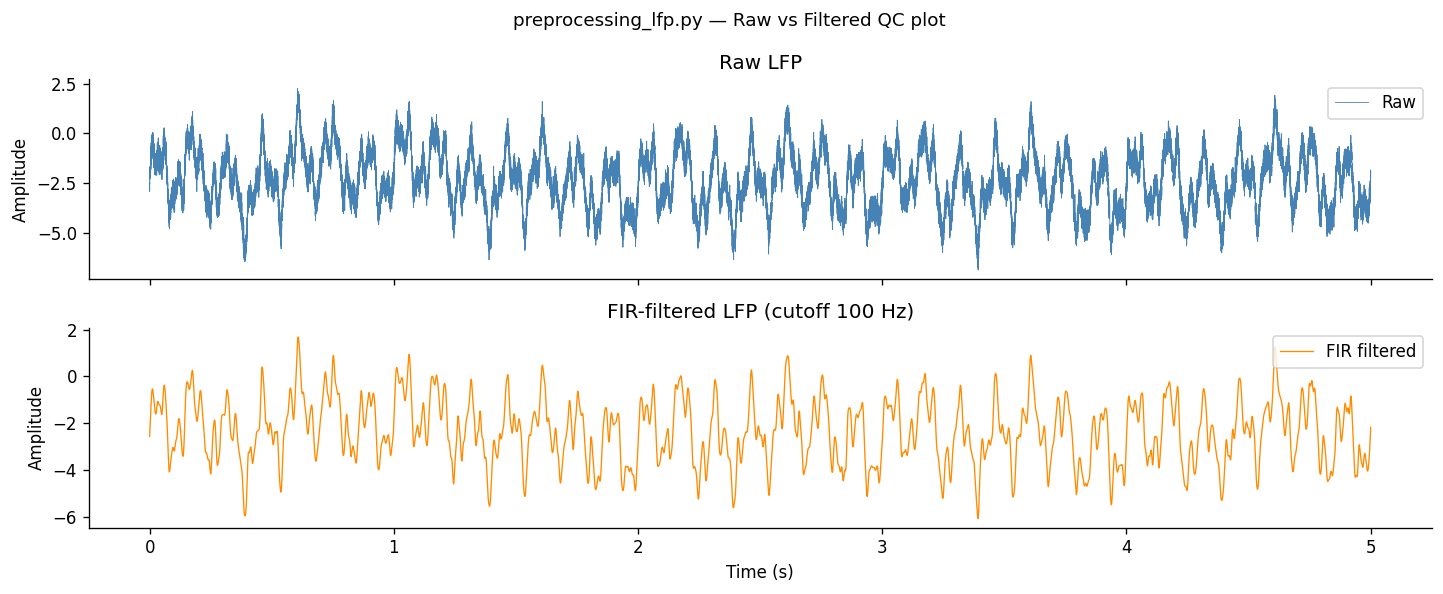

In [16]:
# ── FIR lowpass filter (100 Hz cutoff) ──────────────────────────────────────
# Implements Functions_preprocessing_lfp.filter_data() with filter_type='FIR'

def fir_lowpass(data, fs, cutoff=100.0, delta1=1e-5, delta2=1e-4,
                transition_width=50.0):
    """Zero-phase FIR lowpass filter. Tap count estimated via Rabiner & Gold (1975)."""
    num_taps = int((2/3) * np.log10(1 / (10 * delta1 * delta2)) * (fs / transition_width))
    print(f"FIR filter: cutoff={cutoff} Hz | num_taps={num_taps}")
    taps = firwin(numtaps=num_taps, cutoff=cutoff, fs=fs, pass_zero='lowpass')
    return filtfilt(taps, [1.0], data)


lfp_filtered = fir_lowpass(lfp_raw, fs_raw)

# QC plot: raw vs filtered
fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=True)
display_s = 5.0  # show 5 seconds
n_disp    = int(display_s * fs_raw)

axes[0].plot(t_raw[:n_disp], lfp_raw[:n_disp], lw=0.5, color='steelblue', label='Raw')
axes[0].set_ylabel("Amplitude"); axes[0].set_title("Raw LFP")
axes[0].legend(loc='upper right')

axes[1].plot(t_raw[:n_disp], lfp_filtered[:n_disp], lw=0.8, color='darkorange', label='FIR filtered')
axes[1].set_xlabel("Time (s)"); axes[1].set_ylabel("Amplitude")
axes[1].set_title("FIR-filtered LFP (cutoff 100 Hz)")
axes[1].legend(loc='upper right')

plt.suptitle("preprocessing_lfp.py — Raw vs Filtered QC plot", fontsize=11)
plt.tight_layout()
plt.show()

In [17]:
# ── Downsampling to 1000 Hz ──────────────────────────────────────────────────
# Implements Functions_preprocessing_lfp.downsample_data()
# Uses polyphase rational resampling (scipy.signal.resample_poly)

from scipy.signal import resample_poly

def downsample(data, original_fs, target_fs):
    """Polyphase rational downsampling with anti-aliasing."""
    gcd        = np.gcd(int(original_fs), int(target_fs))
    up_factor  = int(target_fs / gcd)
    dn_factor  = int(original_fs / gcd)
    return resample_poly(data, up_factor, dn_factor)


fs_lfp    = 1000  # target LFP sampling rate (Hz)
lfp_ds    = downsample(lfp_filtered, fs_raw, fs_lfp)
t_lfp     = np.arange(len(lfp_ds)) / fs_lfp

print(f"After downsampling: {len(lfp_ds)} samples at {fs_lfp} Hz ({len(lfp_ds)/fs_lfp:.0f} s)")

# ── Differential referencing (LMR) ──────────────────────────────────────────
# In the real pipeline, a second channel is loaded and subtracted.
# Here we simulate a reference channel as correlated noise.
rng       = np.random.default_rng(99)
lfp_ref   = downsample(fir_lowpass(0.3 * lfp_raw + 0.1 * rng.standard_normal(len(lfp_raw)), fs_raw), fs_raw, fs_lfp)
lfp_lmr   = lfp_ds - lfp_ref  # local field subtraction

print("\nDifferential referencing (LMR): signal = ch_a - ch_b")
print(f"  LMR signal std: {lfp_lmr.std():.4f}  (raw std: {lfp_ds.std():.4f})")

# Save synthetic pkl (mimics real preprocessing output structure)
tmpdir = tempfile.mkdtemp()
pkl_path = os.path.join(tmpdir, 'preprocessed_lfp_referenced_ch31_ref29.pkl')
with open(pkl_path, 'wb') as f:
    pickle.dump({
        'downsampled_data': lfp_lmr,
        'channel': 31,
        'reference': 29,
        'settings': {'downsampling_Hz': fs_lfp},
        'fs_original': float(fs_raw),
        'suffix': 'referenced',
    }, f)
print(f"\npkl saved to: {pkl_path}")

After downsampling: 600000 samples at 1000 Hz (600 s)
FIR filter: cutoff=100.0 Hz | num_taps=2560

Differential referencing (LMR): signal = ch_a - ch_b
  LMR signal std: 0.7654  (raw std: 1.0934)

pkl saved to: C:\Users\Juliana\AppData\Local\Temp\tmpe3wepax4\preprocessed_lfp_referenced_ch31_ref29.pkl


### Note: CAR preprocessing for floating-reference animals

Three early ChR2 animals (ID0714, ID0895, ID0896) were recorded with a disconnected headstage jumper wire, resulting in separate ground and reference potentials (floating reference). Standard differential referencing (LMR) did not adequately suppress noise in these animals.

For these animals, `preprocessing_lfp_car.py` is used instead. The Common Average Reference (CAR) is computed as the instantaneous mean across all channels of one hemisphere and subtracted from each individual channel:

```python
# CAR = mean across all channels of one hemisphere
car = np.mean(np.vstack(raw_signals), axis=0)
corrected_channel = raw_channel - car
```

This removes the shared noise floor that LMR failed to capture. The corrected signals are exported with suffix `referenced_car` and processed identically to the standard `referenced` signals in all downstream scripts.

---
## Step 4 — PSD Analysis (`process_lfp_psd.py`)

Power spectral density (PSD) analysis compares LFP spectral content between baseline and stimulation epochs.

**Workflow:**
1. Apply NLMS adaptive filter using the noise reference channel to remove environmental noise
2. Segment signal into baseline and stimulation epochs (from Pynapse call log or pTrain)
3. Compute Welch PSD per channel per epoch (2 s segments → 0.5 Hz resolution)
4. Average channels within animal → one PSD per animal
5. Average animals → group mean ± SEM
6. Compute Cohen's d per frequency bin + 95% bootstrap CI on Δ power
7. Export: group CSV + 3-panel figure (PSD | Δ power ± CI | Cohen's d)

In [18]:
# ── NLMS adaptive noise filter ───────────────────────────────────────────────
# The noise reference channel (no electrode in brain) records environmental
# noise. NLMS adaptively estimates and subtracts the noise contribution.

def nlms_filter(signal, reference, mu=0.015, n_taps=60):
    """
    Normalized Least Mean Squares adaptive filter.
    Removes broadband noise correlated with the reference channel.

    Parameters
    ----------
    signal    : np.ndarray — LFP channel to denoise
    reference : np.ndarray — noise reference channel (z-scored)
    mu        : float — step size (0.015 in pipeline)
    n_taps    : int — filter length.
                In the real pipeline: int(fs / 50) * NLMS_N_TAPS_FACTOR
                = int(1000 / 50) * 3 = 60 at fs=1000 Hz (default here).
    """
    if len(reference) != len(signal):
        reference = np.interp(
            np.linspace(0, 1, len(signal)),
            np.linspace(0, 1, len(reference)),
            reference,
        )
    weights    = np.zeros(n_taps)
    output     = np.zeros_like(signal)
    buf        = np.zeros(n_taps)
    for i in range(len(signal)):
        buf[:-1] = buf[1:]; buf[-1] = reference[i]
        est      = np.dot(weights, buf)
        err      = signal[i] - est
        weights += (mu / (np.dot(buf, buf) + 1e-6)) * err * buf
        output[i] = err
    return output


# Synthetic noise reference: correlated with environmental noise
rng       = np.random.default_rng(123)
noise_ref = 0.5 * rng.standard_normal(len(lfp_lmr))  # z-scored noise ref
lfp_denoised = nlms_filter(lfp_lmr, noise_ref)
print(f"After NLMS: std before={lfp_lmr.std():.4f}  after={lfp_denoised.std():.4f}")

After NLMS: std before=0.7654  after=0.7744


In [19]:
# ── Epoch segmentation ───────────────────────────────────────────────────────
# In the real pipeline, epoch boundaries are read from Pynapse_call_log.csv
# (generated by TDT Pynapse during recording).
# For ChR2: call log used (short trigger pulses)
# For vSWO/vLWO: pTrain file used (continuous stimulation)

# Epoch windows: 300 s baseline followed by 300 s stimulation.
# In the real pipeline, these boundaries are derived from the
# Pynapse call log (ChR2) or pTrain file (vSWO/vLWO).
BASELINE_DUR_S = 300.0
STIM_DUR_S     = 300.0
stim_onset     = BASELINE_DUR_S   # stimulation starts at 300 s

baseline_win = [(0.0,        stim_onset)]
stim_win     = [(stim_onset, stim_onset + STIM_DUR_S)]

def segment(data, fs, windows):
    """Concatenate segments of data defined by (start_s, end_s) windows."""
    parts = []
    for a, b in windows:
        s, e = int(a * fs), int(b * fs)
        parts.append(data[s:e])
    return np.concatenate(parts) if parts else np.zeros(0)

seg_base = segment(lfp_denoised, fs_lfp, baseline_win)
seg_stim = segment(lfp_denoised, fs_lfp, stim_win)
print(f"Baseline segment: {len(seg_base)/fs_lfp:.0f} s | Stim segment: {len(seg_stim)/fs_lfp:.0f} s")

Baseline segment: 300 s | Stim segment: 300 s


In [20]:
# ── Welch PSD ────────────────────────────────────────────────────────────────
# nperseg = 2 s * 1000 Hz = 2000 samples → frequency resolution = 0.5 Hz

nperseg   = int(2.0 * fs_lfp)  # 2-second segments
freq_range = (0.0, 100.0)       # Hz

freqs_full, psd_base = welch(seg_base, fs=fs_lfp, nperseg=nperseg)
_,          psd_stim = welch(seg_stim, fs=fs_lfp, nperseg=nperseg)

freq_mask = (freqs_full >= freq_range[0]) & (freqs_full <= freq_range[1])
freqs     = freqs_full[freq_mask]
psd_base  = psd_base[freq_mask]
psd_stim  = psd_stim[freq_mask]

print(f"PSD frequency resolution: {freqs[1]-freqs[0]:.2f} Hz | bins: {len(freqs)}")

PSD frequency resolution: 0.50 Hz | bins: 201


In [21]:
# ── Cohen's d + Bootstrap CI ─────────────────────────────────────────────────
# In the real pipeline, PSDs from multiple animals are stacked (n_animals × n_freqs).
# Here we simulate 3 animals by adding small perturbations to the single synthetic PSD.

rng = np.random.default_rng(0)
n_animals = 3
arr_base  = np.vstack([psd_base * (1 + 0.1 * rng.standard_normal(len(freqs))) for _ in range(n_animals)])
arr_stim  = np.vstack([psd_stim * (1 + 0.1 * rng.standard_normal(len(freqs))) for _ in range(n_animals)])

mean_base = arr_base.mean(axis=0)
sem_base  = arr_base.std(axis=0, ddof=1) / np.sqrt(n_animals)
mean_stim = arr_stim.mean(axis=0)
sem_stim  = arr_stim.std(axis=0, ddof=1) / np.sqrt(n_animals)

def cohen_d_vec(base, stim):
    """Cohen's d per frequency bin (stim - base, pooled SD)."""
    diff = stim.mean(0) - base.mean(0)
    sd   = np.sqrt((base.std(0, ddof=1)**2 + stim.std(0, ddof=1)**2) / 2)
    return np.where(sd < 1e-10, 0.0, diff / sd)

def bootstrap_ci(base, stim, n_boot=2000, ci=95, seed=42):
    """Bootstrap 95% CI on mean difference (stim - base) per frequency bin."""
    rng_b = np.random.default_rng(seed)
    diffs = []
    n = base.shape[0]
    for _ in range(n_boot):
        idx = rng_b.integers(0, n, n)
        diffs.append((stim[idx] - base[idx]).mean(0))
    diffs = np.array(diffs)
    lo = np.percentile(diffs, (100 - ci) / 2, axis=0)
    hi = np.percentile(diffs, 100 - (100 - ci) / 2, axis=0)
    return diffs.mean(0), lo, hi

cohens_d    = cohen_d_vec(arr_base, arr_stim)
delta_mean, delta_lo, delta_hi = bootstrap_ci(arr_base, arr_stim)
print(f"Cohen's d range: [{cohens_d.min():.2f}, {cohens_d.max():.2f}]")

Cohen's d range: [-118.81, -3.51]


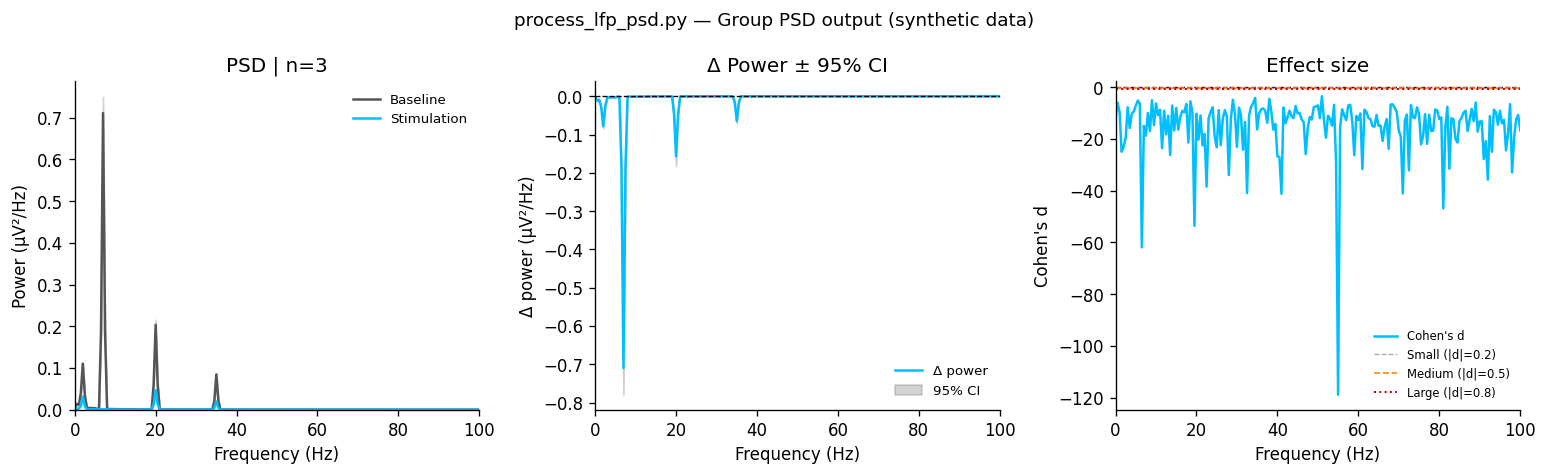


Effect size bands (supplement table):
Level      Band (Hz)       Mean d     N bins
---------------------------------------------
small      0.0-100.0 Hz       -15.308    201
medium     0.0-100.0 Hz       -15.308    201
large      0.0-100.0 Hz       -15.308    201


In [22]:
# ── 3-panel PSD figure ───────────────────────────────────────────────────────
# Reproduces the main output figure of process_lfp_psd.py (3 panels).
# Effect size bands are shown separately in the supplement table (see below).

THRESHOLDS = {'small': -0.2, 'medium': -0.5, 'large': -0.8}
T_STYLES   = {
    'small':  {'color': '#AAAAAA', 'ls': '--', 'lw': 0.8,  'label': 'Small (|d|=0.2)'},
    'medium': {'color': '#FF8800', 'ls': '--', 'lw': 1.0,  'label': 'Medium (|d|=0.5)'},
    'large':  {'color': '#CC0000', 'ls': ':',  'lw': 1.2,  'label': 'Large (|d|=0.8)'},
}
STIM_COLOR = '#00BFFF'
BASE_COLOR = '#555555'

fig, axes = plt.subplots(1, 3, figsize=(13, 4))

# Panel 1: PSD
ax = axes[0]
ax.plot(freqs, mean_base, color=BASE_COLOR, lw=1.5, label='Baseline')
ax.fill_between(freqs, mean_base-sem_base, mean_base+sem_base, color=BASE_COLOR, alpha=0.25)
ax.plot(freqs, mean_stim, color=STIM_COLOR, lw=1.5, label='Stimulation')
ax.fill_between(freqs, mean_stim-sem_stim, mean_stim+sem_stim, color=STIM_COLOR, alpha=0.25)
ax.set_xlabel('Frequency (Hz)'); ax.set_ylabel('Power (µV²/Hz)')
ax.set_title(f'PSD | n={n_animals}'); ax.legend(frameon=False, fontsize=8)
ax.set_xlim(freq_range); ax.set_ylim(bottom=0)

# Panel 2: Delta power + CI
ax = axes[1]
ax.plot(freqs, delta_mean, color=STIM_COLOR, lw=1.5, label='Δ power')
ax.fill_between(freqs, delta_lo, delta_hi, color='gray', alpha=0.35, label='95% CI')
ax.axhline(0, color='black', lw=0.8, ls='--')
ax.set_xlabel('Frequency (Hz)'); ax.set_ylabel('Δ power (µV²/Hz)')
ax.set_title('Δ Power ± 95% CI'); ax.legend(frameon=False, fontsize=8)
ax.set_xlim(freq_range)

# Panel 3: Cohen's d
ax = axes[2]
ax.plot(freqs, cohens_d, color=STIM_COLOR, lw=1.5, label="Cohen's d")
ax.axhline(0, color='black', lw=0.8, ls='--')
for level, thr in THRESHOLDS.items():
    ts = T_STYLES[level]
    ax.axhline(thr, color=ts['color'], lw=ts['lw'], ls=ts['ls'], label=ts['label'])
ax.set_xlabel('Frequency (Hz)'); ax.set_ylabel("Cohen's d")
ax.set_title('Effect size'); ax.legend(frameon=False, fontsize=7, loc='lower right')
ax.set_xlim(freq_range)

fig.suptitle('process_lfp_psd.py — Group PSD output (synthetic data)', fontsize=11)
plt.tight_layout()
plt.show()

# ── Supplement: Effect size bands table ──────────────────────────────────────
# In the real pipeline this is saved as SupplementTable_Bands_*.png
print("\nEffect size bands (supplement table):")
print(f"{'Level':<10} {'Band (Hz)':<15} {'Mean d':<10} {'N bins'}")
print("-" * 45)
for level, thr in THRESHOLDS.items():
    mask = cohens_d < thr
    labeled, n_feat = ndlabel(mask)
    if n_feat == 0:
        print(f"{level:<10} {'None':<15}")
        continue
    for j in range(1, n_feat + 1):
        idx = np.where(labeled == j)[0]
        fl, fh  = freqs[idx[0]], freqs[idx[-1]]
        d_mean  = cohens_d[idx].mean()
        print(f"{level:<10} {fl:.1f}-{fh:.1f} Hz{'':<6} {d_mean:<10.3f} {len(idx)}")


---
## Step 5 — FOOOF / specparam Analysis (`process_lfp_fooof.py`)

FOOOF (Fitting Oscillations & One Over F; Donoghue et al., 2020, *Nature Neuroscience*) — now maintained as `specparam` — parameterizes a power spectrum into two components:

- **Aperiodic component**: the 1/f-like background, described by an *offset* (overall power level in log space) and an *exponent* (spectral slope)
- **Periodic components**: oscillatory peaks above the aperiodic background, each described by center frequency (CF), power (PW), and bandwidth (BW)

**Important**: FOOOF is used as an **exploratory, supplementary analysis** in this paper. The primary LFP findings are based on the Welch PSD analysis in Step 4.

In [23]:
# ── FOOOF fit ────────────────────────────────────────────────────────────────
# Settings used in process_lfp_fooof.py
FOOOF_FREQ_RANGE       = [1.0, 100.0]   # Hz — fitting range
PEAK_WIDTH_LIMITS      = [1.0, 12.0]    # Hz — min/max peak width
MAX_N_PEAKS            = 6
MIN_PEAK_HEIGHT        = 0.05           # log power units above aperiodic
APERIODIC_MODE         = 'knee'         # 'fixed' or 'knee'

def fit_fooof(freqs, psd, label=''):
    """
    Fit a specparam model and extract aperiodic + peak parameters.
    Returns a dict with offset, exponent, r_squared, and per-peak CF/PW/BW.
    """
    fm = FOOOF(
        peak_width_limits=PEAK_WIDTH_LIMITS,
        max_n_peaks=MAX_N_PEAKS,
        min_peak_height=MIN_PEAK_HEIGHT,
        aperiodic_mode=APERIODIC_MODE,
        verbose=False,
    )
    fm.fit(freqs, psd, FOOOF_FREQ_RANGE)

    # Extract parameters — specparam stores results in fm.results
    metrics  = fm.results.metrics.results
    ap_dict  = fm.results.params.aperiodic.asdict()
    pk_dict  = fm.results.params.periodic.asdict()

    ap_fit   = np.asarray(ap_dict.get('aperiodic_fit', []), dtype=float).ravel()
    ap_fit   = ap_fit[np.isfinite(ap_fit)]

    if len(ap_fit) == 2:
        offset, exponent = float(ap_fit[0]), float(ap_fit[1])
    elif len(ap_fit) == 3:
        offset, _, exponent = float(ap_fit[0]), float(ap_fit[1]), float(ap_fit[2])
    else:
        offset = exponent = float('nan')

    pk_fit   = np.asarray(pk_dict.get('peak_fit', []), dtype=float)
    peaks    = pk_fit[np.isfinite(pk_fit[:, 0])] if pk_fit.ndim == 2 and pk_fit.shape[1] == 3 and len(pk_fit) > 0 else np.empty((0, 3))

    result = {
        'label':      label,
        'r_squared':  float(metrics.get('gof_rsquared', float('nan'))),
        'error_mae':  float(metrics.get('error_mae',    float('nan'))),
        'offset':     offset,
        'exponent':   exponent,
        'n_peaks':    len(peaks),
        'peaks':      peaks,  # (n_peaks, 3): [CF, PW, BW]
        'model':      fm,
    }
    print(f"  {label}: R²={result['r_squared']:.3f} | offset={offset:.3f} | exponent={exponent:.3f} | n_peaks={len(peaks)}")
    return result


print("Fitting FOOOF models...")
res_base = fit_fooof(freqs, psd_base, label='Baseline')
res_stim = fit_fooof(freqs, psd_stim, label='Stimulation')

print(f"\nΔ offset:   {res_stim['offset']   - res_base['offset']:.3f}")
print(f"Δ exponent: {res_stim['exponent'] - res_base['exponent']:.3f}")

Fitting FOOOF models...
  Baseline: R²=0.948 | offset=-1.054 | exponent=1.619 | n_peaks=4
  Stimulation: R²=0.935 | offset=-1.725 | exponent=1.587 | n_peaks=3

Δ offset:   -0.671
Δ exponent: -0.032


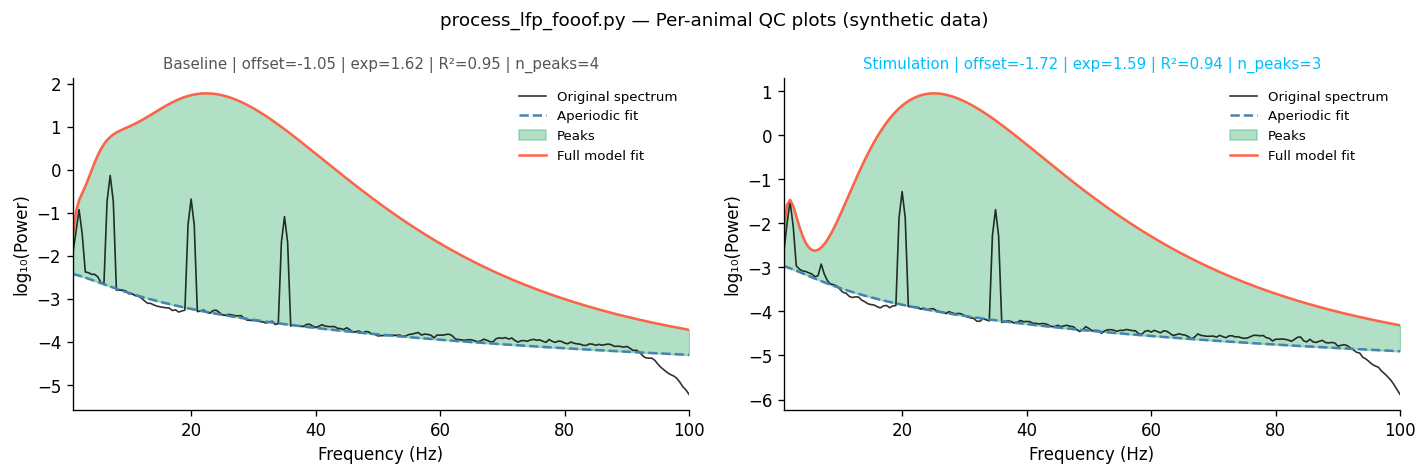

In [24]:
# ── FOOOF QC plot — manual model reconstruction ──────────────────────────────
# specparam's fm.plot() API changed across versions and may not support
# the ax= keyword in all releases. We reconstruct the model manually instead:
#   Full model = aperiodic background + sum of Gaussian peaks
# This is equivalent to what FOOOF displays internally.

def reconstruct_fooof_model(fm, freqs_plot):
    """
    Reconstruct the full FOOOF model fit from parameters.
    Returns log10 power values for: aperiodic background, full model.
    """
    res      = fm.results
    ap_dict  = res.params.aperiodic.asdict()
    pk_dict  = res.params.periodic.asdict()

    # Aperiodic: reconstruct from offset + exponent (fixed mode)
    # or offset + knee + exponent (knee mode)
    ap_fit  = np.asarray(ap_dict.get('aperiodic_fit', []), dtype=float).ravel()
    ap_fit  = ap_fit[np.isfinite(ap_fit)]

    log_f   = np.log10(freqs_plot)
    if len(ap_fit) == 2:
        aperiodic_log = ap_fit[0] - ap_fit[1] * log_f
    elif len(ap_fit) == 3:
        # knee mode: offset - log10(knee + f^exponent)
        aperiodic_log = ap_fit[0] - np.log10(ap_fit[1] + freqs_plot ** ap_fit[2])
    else:
        aperiodic_log = np.zeros_like(freqs_plot)

    # Peaks: sum of Gaussians in log power space
    pk_fit  = np.asarray(pk_dict.get('peak_fit', []), dtype=float)
    peaks_log = np.zeros_like(freqs_plot)
    if pk_fit.ndim == 2 and pk_fit.shape[1] == 3:
        for cf, pw, bw in pk_fit:
            if np.isfinite(cf) and bw > 0:
                peaks_log += pw * np.exp(-0.5 * ((log_f - np.log10(cf)) / (bw / 2)) ** 2)

    full_model_log = aperiodic_log + peaks_log
    return aperiodic_log, full_model_log


fig, axes = plt.subplots(1, 2, figsize=(12, 4))
freq_mask_fooof = (freqs >= FOOOF_FREQ_RANGE[0]) & (freqs <= FOOOF_FREQ_RANGE[1])
freqs_f  = freqs[freq_mask_fooof]
log_f    = np.log10(freqs_f)

for ax, res, psd_plot, label_color in [
    (axes[0], res_base, psd_base, BASE_COLOR),
    (axes[1], res_stim, psd_stim, STIM_COLOR),
]:
    psd_f   = psd_plot[freq_mask_fooof]
    log_psd = np.log10(psd_f + 1e-12)  # convert to log10

    ap_log, full_log = reconstruct_fooof_model(res['model'], freqs_f)

    ax.plot(freqs_f, log_psd,  color='black',   lw=1.0, label='Original spectrum', alpha=0.8)
    ax.plot(freqs_f, ap_log,   color='steelblue', lw=1.5, ls='--', label='Aperiodic fit')
    ax.fill_between(freqs_f, ap_log, full_log,
                    color='mediumseagreen', alpha=0.4, label='Peaks')
    ax.plot(freqs_f, full_log, color='tomato',   lw=1.5, label='Full model fit')

    ax.set_title(
        f"{res['label']} | offset={res['offset']:.2f} | exp={res['exponent']:.2f} | "
        f"R²={res['r_squared']:.2f} | n_peaks={res['n_peaks']}",
        color=label_color, fontsize=9,
    )
    ax.set_xlabel('Frequency (Hz)'); ax.set_ylabel('log₁₀(Power)')
    ax.set_xlim(FOOOF_FREQ_RANGE)
    ax.legend(frameon=False, fontsize=8)

fig.suptitle('process_lfp_fooof.py — Per-animal QC plots (synthetic data)', fontsize=11)
plt.tight_layout()
plt.show()


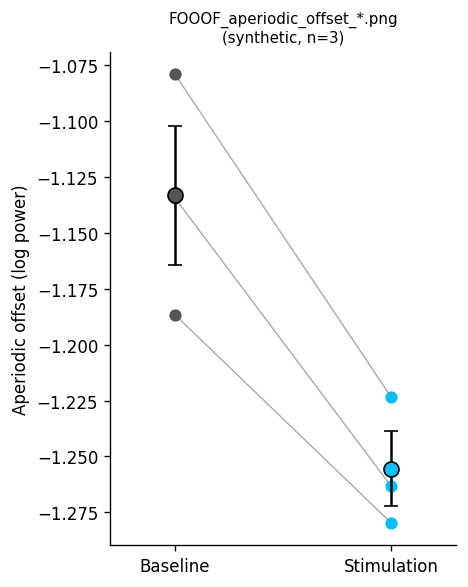

Mean offset: baseline=-1.133 | stim=-1.255
Δ offset: -0.122


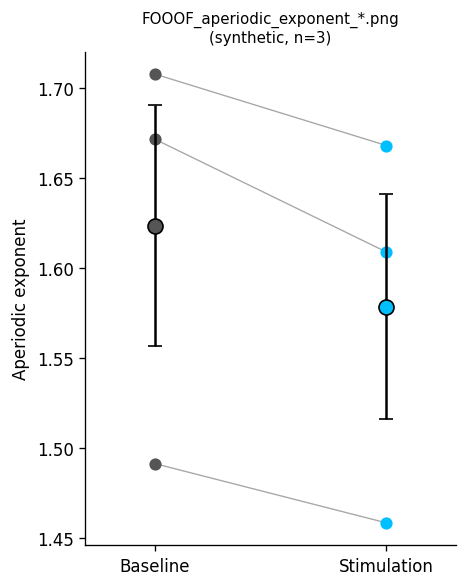

Exponent: baseline=1.623 | stim=1.578
Δ exponent: -0.045


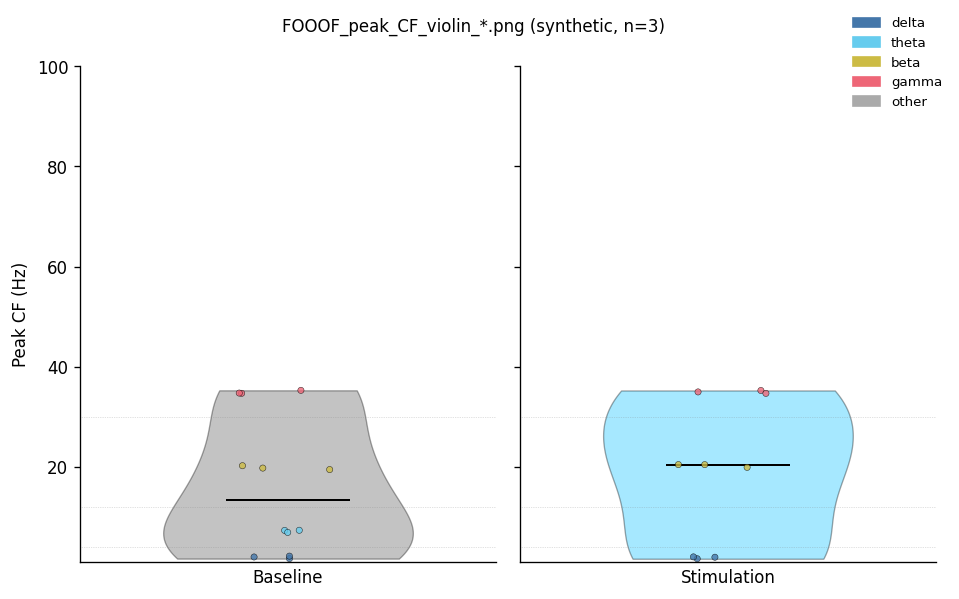

In [25]:
# ── Summary: Aperiodic offset paired plot ────────────────────────────────────
# In the real pipeline this is produced for all animals in the cohort.
# Here we show the concept with simulated per-animal values.

# Simulate n=3 animals
rng = np.random.default_rng(5)
offsets_base = np.array([res_base['offset'] + 0.1 * rng.standard_normal() for _ in range(3)])
offsets_stim = offsets_base - 0.15 + 0.05 * rng.standard_normal(3)  # stimulation reduces offset

fig, ax = plt.subplots(figsize=(4, 5))
for b, s in zip(offsets_base, offsets_stim):
    ax.plot([0, 1], [b, s], color='gray', lw=0.8, alpha=0.7)
    ax.scatter([0], [b], color=BASE_COLOR, s=40, zorder=3)
    ax.scatter([1], [s], color=STIM_COLOR, s=40, zorder=3)

for x, vals, col in [(0, offsets_base, BASE_COLOR), (1, offsets_stim, STIM_COLOR)]:
    ax.errorbar(x, vals.mean(), yerr=vals.std(ddof=1)/np.sqrt(3),
                fmt='o', color='black', markerfacecolor=col,
                markersize=9, capsize=4, elinewidth=1.5, zorder=5)

ax.set_xticks([0, 1]); ax.set_xticklabels(['Baseline', 'Stimulation'])
ax.set_ylabel('Aperiodic offset (log power)')
ax.set_title('FOOOF_aperiodic_offset_*.png\n(synthetic, n=3)', fontsize=9)
ax.set_xlim(-0.3, 1.3)
plt.tight_layout()
plt.show()

print(f"Mean offset: baseline={offsets_base.mean():.3f} | stim={offsets_stim.mean():.3f}")
print(f"Δ offset: {(offsets_stim - offsets_base).mean():.3f}")

# ── Aperiodic exponent paired plot ───────────────────────────────────────────
# Shows the spectral slope change. A decrease = flatter spectrum during stim.

rng2 = np.random.default_rng(6)
exp_base = np.array([res_base['exponent'] + 0.05 * rng2.standard_normal() for _ in range(3)])
exp_stim = exp_base - 0.06 + 0.02 * rng2.standard_normal(3)

fig, ax = plt.subplots(figsize=(4, 5))
for b, s in zip(exp_base, exp_stim):
    ax.plot([0, 1], [b, s], color='gray', lw=0.8, alpha=0.7)
    ax.scatter([0], [b], color=BASE_COLOR, s=40, zorder=3)
    ax.scatter([1], [s], color=STIM_COLOR, s=40, zorder=3)
for x, vals, col in [(0, exp_base, BASE_COLOR), (1, exp_stim, STIM_COLOR)]:
    ax.errorbar(x, vals.mean(), yerr=vals.std(ddof=1)/np.sqrt(3),
                fmt='o', color='black', markerfacecolor=col,
                markersize=9, capsize=4, elinewidth=1.5, zorder=5)
ax.set_xticks([0, 1]); ax.set_xticklabels(['Baseline', 'Stimulation'])
ax.set_ylabel('Aperiodic exponent')
ax.set_title('FOOOF_aperiodic_exponent_*.png\n(synthetic, n=3)', fontsize=9)
ax.set_xlim(-0.3, 1.3)
plt.tight_layout()
plt.show()

print(f"Exponent: baseline={exp_base.mean():.3f} | stim={exp_stim.mean():.3f}")
print(f"Δ exponent: {(exp_stim - exp_base).mean():.3f}")

# ── Peak CF violin plot ───────────────────────────────────────────────────────
# Shows the distribution of extracted peak center frequencies across animals.
# Each point is one peak from one animal, coloured by frequency band.
# The violin shows the kernel density estimate of the CF distribution.

FREQ_BANDS = {
    'delta': (1.0,   4.0),
    'theta': (4.0,  12.0),
    'beta':  (12.0, 30.0),
    'gamma': (30.0, 100.0),
}
BAND_COLORS = {
    'delta': '#4477AA', 'theta': '#66CCEE',
    'beta':  '#CCBB44', 'gamma': '#EE6677', 'other': '#AAAAAA',
}

def band_label(cf):
    for name, (lo, hi) in FREQ_BANDS.items():
        if lo <= cf < hi:
            return name
    return 'other'

# Collect all peak CFs from baseline and stim fits
# In the real pipeline this comes from FOOOF_peaks_*.csv (all animals pooled)
rng3 = np.random.default_rng(7)
all_cf_base, all_cf_stim = [], []
for res, cf_list in [(res_base, all_cf_base), (res_stim, all_cf_stim)]:
    for _ in range(3):  # simulate 3 animals
        for cf, pw, bw in res['peaks']:
            if np.isfinite(cf):
                cf_list.append(cf + rng3.uniform(-0.5, 0.5))

fig, axes = plt.subplots(1, 2, figsize=(8, 5), sharey=True)
for ax, cfs, condition, color in [
    (axes[0], all_cf_base, 'Baseline',    BASE_COLOR),
    (axes[1], all_cf_stim, 'Stimulation', STIM_COLOR),
]:
    if len(cfs) > 1:
        parts = ax.violinplot(cfs, positions=[0], widths=0.6,
                              showmedians=True, showextrema=False)
        for pc in parts['bodies']:
            pc.set_facecolor(color); pc.set_alpha(0.35)
            pc.set_edgecolor('black'); pc.set_linewidth(0.8)
        parts['cmedians'].set_color('black'); parts['cmedians'].set_linewidth(1.2)
    jitter = rng3.uniform(-0.12, 0.12, size=len(cfs))
    colors = [BAND_COLORS[band_label(cf)] for cf in cfs]
    ax.scatter(jitter, cfs, c=colors, s=14, alpha=0.8, zorder=4,
               edgecolors='black', linewidths=0.3)
    # Band boundary lines
    for _, (lo, hi) in FREQ_BANDS.items():
        ax.axhline(lo, color='gray', lw=0.4, ls=':', alpha=0.5)
    ax.set_xlim(-0.5, 0.5); ax.set_xticks([]); ax.set_xlabel(condition)
    ax.set_ylim([1, 100])

axes[0].set_ylabel('Peak CF (Hz)')

from matplotlib.patches import Patch
handles = [Patch(color=c, label=b) for b, c in BAND_COLORS.items()]
fig.legend(handles=handles, loc='upper right', fontsize=8,
           frameon=False, bbox_to_anchor=(1.0, 1.0))
fig.suptitle('FOOOF_peak_CF_violin_*.png (synthetic, n=3)', fontsize=10)
plt.tight_layout()
plt.show()


---
## Summary — Output Files

```
Postprocessing/
├── LFP_PSD/{region}/{kind}/{window_suffix}/
│   ├── GroupPSD_*.csv               (freq, mean, SEM, Cohen's d, p_fdr, CI)
│   ├── PSD_*.png / .svg             (3-panel: PSD | Δ power ± CI | Cohen's d)
│   ├── SignificantBands_*.csv        (frequency bands exceeding Cohen's d thresholds)
│   └── SupplementTable_Bands_*.png  (supplement table figure)
│
└── LFP_FOOOF/{region}/{kind}/{window_suffix}/
    ├── FOOOF_results_*.csv          (offset, exponent, peak CF/PW/BW per animal)
    ├── FOOOF_peaks_*.csv            (all extracted peak CFs)
    ├── FOOOF_aperiodic_offset_*.png / .svg
    ├── FOOOF_aperiodic_exponent_*.png / .svg
    ├── FOOOF_peak_CF_violin_*.png / .svg
    └── {folder}/
        ├── FOOOF_baseline_{folder}.png  (per-animal QC fit)
        └── FOOOF_stim_{folder}.png      (per-animal QC fit)
```

**Signal kinds** (`{kind}`):
- `referenced` — LMR differential referencing (standard animals)
- `unreferenced` — single-wire, no referencing
- `referenced_car` — CAR-corrected (early ChR2 animals 0714/0895/0896)

---
## References

- Donoghue, T., Haller, M., Peterson, E.J., et al. (2020). Parameterizing neural power spectra into periodic and aperiodic components. *Nature Neuroscience*, 23, 1655–1665. https://doi.org/10.1038/s41593-020-00744-x
- Ho, J., Tumkaya, T., Aryal, S., et al. (2019). Moving beyond P values: data analysis with estimation graphics. *Nature Methods*, 16, 565–566. https://doi.org/10.1038/s41592-019-0470-3